In [1]:
# ============================================================
# LIBRARIES & DISPLAY SETTINGS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, rankdata
from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# LOAD ED VISITS DATASET FROM FINALIZED WORKBOOK
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-"
    r"\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-"
    r"\data\cleaned dataset"
    r"\Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx"
)

ED_VISITS_SHEET = "ED_Visits"

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"\nED Visits workbook not found:\n{INPUT_FILE}\n"
        "Please check the file path."
    )

ed_df = pd.read_excel(
    INPUT_FILE,
    sheet_name=ED_VISITS_SHEET
)

print(f"Loaded {len(ed_df):,} rows from {ED_VISITS_SHEET}.")
display(ed_df.head())

Loaded 7,296 rows from ED_Visits.


,fiscal_year,fiscal_year_start,triage_level,ctas_urgency_score,visit_disposition,main_problem,admission_status,ed_visits,median_los_minutes,median_los_hours,admission_flag
0,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Acute Myocardial Infarction,Admitted,1360,93,1.5500,1
1,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Any,Admitted,77562,420,7.0000,1
2,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Asthma,Admitted,822,456,7.6000,1
3,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Influenzal Pneumonia,Admitted,0,0,0.0000,1
4,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Motor Vehicle Collisions,Admitted,3032,324,5.4000,1


In [3]:
# ============================================================
# STANDARDIZE COLUMN NAMES & SHAPE
# ============================================================

ed_df.columns = (
    ed_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("=" * 80)
print("COLUMN NAMES & DATASET SHAPE")
print("=" * 80)

print(f"Rows    : {ed_df.shape[0]:,}")
print(f"Columns : {ed_df.shape[1]}")
print("\nColumns:")
print(ed_df.columns.tolist())

COLUMN NAMES & DATASET SHAPE
Rows    : 7,296
Columns : 11

Columns:
['fiscal_year', 'fiscal_year_start', 'triage_level', 'ctas_urgency_score', 'visit_disposition', 'main_problem', 'admission_status', 'ed_visits', 'median_los_minutes', 'median_los_hours', 'admission_flag']


In [4]:
# ============================================================
# DATA INSPECTION
# ============================================================

print("FIRST 5 ROWS")
print("-" * 80)
display(ed_df.head())

print("\nDATA TYPES & MISSING VALUES")
print("-" * 80)
data_info = pd.DataFrame({
    "Data Type": ed_df.dtypes,
    "Missing Values": ed_df.isna().sum(),
    "Unique Values": ed_df.nunique()
})
display(data_info)

FIRST 5 ROWS
--------------------------------------------------------------------------------


,fiscal_year,fiscal_year_start,triage_level,ctas_urgency_score,visit_disposition,main_problem,admission_status,ed_visits,median_los_minutes,median_los_hours,admission_flag
0,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Acute Myocardial Infarction,Admitted,1360,93,1.5500,1
1,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Any,Admitted,77562,420,7.0000,1
2,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Asthma,Admitted,822,456,7.6000,1
3,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Influenzal Pneumonia,Admitted,0,0,0.0000,1
4,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Motor Vehicle Collisions,Admitted,3032,324,5.4000,1



DATA TYPES & MISSING VALUES
--------------------------------------------------------------------------------


,Data Type,Missing Values,Unique Values
fiscal_year,str,0,19
fiscal_year_start,int64,0,19
triage_level,str,0,6
ctas_urgency_score,int64,0,3
visit_disposition,str,0,8
main_problem,str,0,8
admission_status,str,0,2
ed_visits,int64,0,2940
median_los_minutes,int64,0,599
median_los_hours,float64,0,599


In [5]:
# ============================================================
# CLEAN REQUIRED NUMERIC VARIABLES
# ============================================================

ed_df["median_los_minutes"] = pd.to_numeric(
    ed_df["median_los_minutes"],
    errors="coerce"
)

ed_df["ed_visits"] = pd.to_numeric(
    ed_df["ed_visits"],
    errors="coerce"
)

ed_df["fiscal_year_start"] = pd.to_numeric(
    ed_df["fiscal_year_start"],
    errors="coerce"
)

# Remove rows with invalid LOS
ed_df = ed_df[
    ed_df["median_los_minutes"].notna()
].copy()

ed_df = ed_df[
    ed_df["median_los_minutes"] >= 0
].copy()

print("=" * 80)
print("DATASET AFTER NUMERIC CLEANING")
print("=" * 80)

print(f"Valid records retained : {len(ed_df):,}")
print(f"Total fiscal years     : {ed_df['fiscal_year_start'].nunique()}")
print(f"Fiscal year range      : {ed_df['fiscal_year_start'].min():.0f} to {ed_df['fiscal_year_start'].max():.0f}")

DATASET AFTER NUMERIC CLEANING
Valid records retained : 7,296
Total fiscal years     : 19
Fiscal year range      : 2003 to 2021


In [6]:
# ============================================================
# STANDARDIZE FISCAL YEAR REPRESENTATION
# ============================================================

def make_fiscal_year_label(year):
    year = int(year)
    return f"{year}-{year + 1}"

if "fiscal_year" not in ed_df.columns or ed_df["fiscal_year"].isna().any():
    ed_df["fiscal_year"] = ed_df["fiscal_year_start"].apply(make_fiscal_year_label)

ed_df["fiscal_year_label"] = ed_df["fiscal_year_start"].apply(make_fiscal_year_label)

fiscal_year_coverage = (
    ed_df
    .groupby(["fiscal_year_start", "fiscal_year_label"], observed=True)
    .agg(
        records=("median_los_minutes", "count"),
        total_visits=("ed_visits", "sum"),
        median_los=("median_los_minutes", "median")
    )
    .reset_index()
    .sort_values("fiscal_year_start")
)

print("=" * 80)
print("FISCAL YEAR COVERAGE")
print("=" * 80)
display(fiscal_year_coverage)

FISCAL YEAR COVERAGE


,fiscal_year_start,fiscal_year_label,records,total_visits,median_los
0,2003,2003-2004,384,13499654,118.0000
1,2004,2004-2005,384,14396234,128.5000
2,2005,2005-2006,384,14782618,118.0000
3,2006,2006-2007,384,14730506,120.0000
4,2007,2007-2008,384,14998926,130.0000
5,2008,2008-2009,384,15044884,128.0000
6,2009,2009-2010,384,15416074,145.0000
7,2010,2010-2011,384,21687972,135.5000
8,2011,2011-2012,384,23595222,139.5000
9,2012,2012-2013,384,25642774,143.0000


In [7]:
# ============================================================
# VALIDATE MATCHING COLUMNS EXIST
# ============================================================

H2_MATCH_COLUMNS = [
    "triage_level",
    "visit_disposition",
    "main_problem",
    "admission_status"
]

print("=" * 80)
print("MATCHING COLUMN AVAILABILITY")
print("=" * 80)

for col in H2_MATCH_COLUMNS:
    status = "FOUND" if col in ed_df.columns else "MISSING"
    print(f"  {col:25} : {status}")

missing_cols = [
    col for col in H2_MATCH_COLUMNS
    if col not in ed_df.columns
]

if missing_cols:
    raise KeyError(
        f"Required matching columns not found in dataset: {missing_cols}\n"
        "Check that the ED_Visits sheet contains these columns."
    )

print("\nAll matching columns are available.")

for col in H2_MATCH_COLUMNS:
    print(f"  {col:<25} Unique categories: {ed_df[col].nunique()}")

MATCHING COLUMN AVAILABILITY
  triage_level              : FOUND
  visit_disposition         : FOUND
  main_problem              : FOUND
  admission_status          : FOUND

All matching columns are available.
  triage_level              Unique categories: 6
  visit_disposition         Unique categories: 8
  main_problem              Unique categories: 8
  admission_status          Unique categories: 2


In [8]:
# ============================================================
# DEFINE H2 COMPARISON PERIODS
# ============================================================
# Pre-pandemic baseline: FY 2017-2018, FY 2018-2019, FY 2019-2020
# Pandemic comparison  : FY 2020-2021

PRE_PANDEMIC_YEARS = [2017, 2018, 2019]
PANDEMIC_YEAR = 2020
ALPHA = 0.05

print("=" * 80)
print("H2 PERIOD DEFINITIONS")
print("=" * 80)

print(
    f"Pre-pandemic baseline  : "
    f"FY {PRE_PANDEMIC_YEARS[0]}-{PRE_PANDEMIC_YEARS[0]+1}, "
    f"FY {PRE_PANDEMIC_YEARS[1]}-{PRE_PANDEMIC_YEARS[1]+1}, "
    f"FY {PRE_PANDEMIC_YEARS[2]}-{PRE_PANDEMIC_YEARS[2]+1}"
)
print(
    f"Pandemic comparison    : FY {PANDEMIC_YEAR}-{PANDEMIC_YEAR+1}"
)
print(f"Significance level (α) : {ALPHA}")

H2 PERIOD DEFINITIONS
Pre-pandemic baseline  : FY 2017-2018, FY 2018-2019, FY 2019-2020
Pandemic comparison    : FY 2020-2021
Significance level (α) : 0.05


In [9]:
# ============================================================
# CREATE PRE-PANDEMIC BASELINE
# ============================================================

pre_df = ed_df[
    ed_df["fiscal_year_start"].isin(
        PRE_PANDEMIC_YEARS
    )
].copy()

pandemic_df = ed_df[
    ed_df["fiscal_year_start"] == PANDEMIC_YEAR
].copy()

pre_baseline = (
    pre_df
    .groupby(
        H2_MATCH_COLUMNS,
        observed=True
    )
    .agg(
        pre_pandemic_median_los=(
            "median_los_minutes",
            "median"
        ),
        pre_pandemic_years=(
            "fiscal_year_start",
            "nunique"
        )
    )
    .reset_index()
)

# Require complete 3-year pre-pandemic reporting
pre_baseline = pre_baseline[
    pre_baseline["pre_pandemic_years"] == len(PRE_PANDEMIC_YEARS)
].copy()

print("=" * 80)
print("PRE-PANDEMIC BASELINE SUMMARY")
print("=" * 80)

print(f"Pre-pandemic records available : {len(pre_df):,}")
print(f"Complete 3-year baseline strata: {len(pre_baseline):,}")
display(pre_baseline.head())


PRE-PANDEMIC BASELINE SUMMARY
Pre-pandemic records available : 1,152
Complete 3-year baseline strata: 384


,triage_level,visit_disposition,main_problem,admission_status,pre_pandemic_median_los,pre_pandemic_years
0,CTAS I - Resuscitation,Admitted,Acute Myocardial Infarction,Admitted,96.0000,3
1,CTAS I - Resuscitation,Admitted,Any,Admitted,384.0000,3
2,CTAS I - Resuscitation,Admitted,Asthma,Admitted,423.0000,3
3,CTAS I - Resuscitation,Admitted,Influenzal Pneumonia,Admitted,657.0000,3
4,CTAS I - Resuscitation,Admitted,Motor Vehicle Collisions,Admitted,300.0000,3


In [10]:
# ============================================================
# MATCH PANDEMIC YEAR (FY 2020-2021) TO BASELINE
# ============================================================

h2_matched = pandemic_df.merge(
    pre_baseline,
    on=H2_MATCH_COLUMNS,
    how="inner",
    validate="one_to_one"
)

h2_matched = h2_matched.rename(
    columns={
        "median_los_minutes": "pandemic_median_los"
    }
)

h2_matched = h2_matched.dropna(
    subset=[
        "pre_pandemic_median_los",
        "pandemic_median_los"
    ]
).copy()

print("=" * 80)
print("MATCHED DATASET CREATED")
print("=" * 80)

print(f"Matched records: {len(h2_matched):,}")
display(
    h2_matched[
        H2_MATCH_COLUMNS
        + ["pre_pandemic_median_los", "pandemic_median_los"]
    ].head()
)


MATCHED DATASET CREATED
Matched records: 384


,triage_level,visit_disposition,main_problem,admission_status,pre_pandemic_median_los,pandemic_median_los
0,CTAS I - Resuscitation,Admitted,Acute Myocardial Infarction,Admitted,96.0000,84
1,CTAS I - Resuscitation,Admitted,Any,Admitted,384.0000,366
2,CTAS I - Resuscitation,Admitted,Asthma,Admitted,423.0000,411
3,CTAS I - Resuscitation,Admitted,Influenzal Pneumonia,Admitted,657.0000,360
4,CTAS I - Resuscitation,Admitted,Motor Vehicle Collisions,Admitted,300.0000,300


In [11]:
# ============================================================
# VALIDATE THE MATCHED STRUCTURE
# ============================================================

print("=" * 80)
print("H2 MATCHED STRUCTURE VALIDATION")
print("=" * 80)

print(f"Pandemic aggregate records                  : {len(pandemic_df):,}")
print(f"Complete pre-pandemic baseline categories   : {len(pre_baseline):,}")
print(f"Matched aggregate categories                : {len(h2_matched):,}")

duplicate_count = (
    h2_matched
    .duplicated(
        subset=H2_MATCH_COLUMNS,
        keep=False
    )
    .sum()
)

print(f"Duplicate matched categories                : {duplicate_count:,}")

if duplicate_count > 0:
    raise ValueError(
        "Duplicate matched categories found in H2 dataset. "
        "Every matched record must represent a unique stratum."
    )

if len(h2_matched) < 10:
    raise ValueError(
        "Too few matched aggregate categories for H2."
    )

print("\nStructure validation passed: 1-to-1 matched aggregate categories with 0 duplicates.")

H2 MATCHED STRUCTURE VALIDATION
Pandemic aggregate records                  : 384
Complete pre-pandemic baseline categories   : 384
Matched aggregate categories                : 384
Duplicate matched categories                : 0

Structure validation passed: 1-to-1 matched aggregate categories with 0 duplicates.


In [12]:
# ============================================================
# CALCULATE PAIRED DIFFERENCES
# ============================================================

h2_matched["los_difference_minutes"] = (
    h2_matched["pandemic_median_los"]
    - h2_matched["pre_pandemic_median_los"]
)

median_difference = h2_matched["los_difference_minutes"].median()
mean_difference = h2_matched["los_difference_minutes"].mean()

print("=" * 80)
print("PAIRED DIFFERENCES (FY 2020-2021 minus Pre-Pandemic Baseline)")
print("=" * 80)

print(f"Median paired difference : {median_difference:.2f} minutes")
print(f"Mean paired difference   : {mean_difference:.2f} minutes")
print(f"Minimum difference       : {h2_matched['los_difference_minutes'].min():.2f} minutes")
print(f"Maximum difference       : {h2_matched['los_difference_minutes'].max():.2f} minutes")
print(f"Pairs with positive diff : {(h2_matched['los_difference_minutes'] > 0).sum():,}")
print(f"Pairs with negative diff : {(h2_matched['los_difference_minutes'] < 0).sum():,}")
print(f"Pairs with zero diff     : {(h2_matched['los_difference_minutes'] == 0).sum():,}")

PAIRED DIFFERENCES (FY 2020-2021 minus Pre-Pandemic Baseline)
Median paired difference : 0.00 minutes
Mean paired difference   : -6.86 minutes
Minimum difference       : -789.00 minutes
Maximum difference       : 1038.00 minutes
Pairs with positive diff : 108
Pairs with negative diff : 171
Pairs with zero diff     : 105


In [13]:
# ============================================================
# DESCRIPTIVE H2 SUMMARY TABLE
# ============================================================

h2_descriptive = pd.DataFrame({
    "Period": [
        "Pre-pandemic baseline",
        "FY 2020–2021"
    ],
    "Matched_Records": [
        len(h2_matched),
        len(h2_matched)
    ],
    "Median_LOS_Minutes": [
        h2_matched["pre_pandemic_median_los"].median(),
        h2_matched["pandemic_median_los"].median()
    ],
    "Mean_LOS_Minutes": [
        h2_matched["pre_pandemic_median_los"].mean(),
        h2_matched["pandemic_median_los"].mean()
    ]
})

print("=" * 80)
print("H2 DESCRIPTIVE SUMMARY")
print("=" * 80)
display(h2_descriptive.round(2))

H2 DESCRIPTIVE SUMMARY


,Period,Matched_Records,Median_LOS_Minutes,Mean_LOS_Minutes
0,Pre-pandemic baseline,384,156.0000,186.2100
1,FY 2020–2021,384,150.0000,179.3500


In [14]:
# ============================================================
# PRIMARY H2 TEST — WILCOXON SIGNED-RANK TEST
# ============================================================

wilcoxon_statistic, p_value = wilcoxon(
    h2_matched["pandemic_median_los"],
    h2_matched["pre_pandemic_median_los"],
    alternative="two-sided",
    zero_method="wilcox",
    method="auto"
)

print("=" * 80)
print("H2 — WILCOXON SIGNED-RANK TEST")
print("=" * 80)

print(f"Wilcoxon statistic (W) : {wilcoxon_statistic:.4f}")
print(f"P-value                : {p_value:.10g}")
print(f"Significance level (α) : {ALPHA}")
print(f"Test type              : Two-sided paired test")

H2 — WILCOXON SIGNED-RANK TEST
Wilcoxon statistic (W) : 14764.0000
P-value                : 0.0004008181377
Significance level (α) : 0.05
Test type              : Two-sided paired test


In [15]:
# ============================================================
# H2 EFFECT SIZE — MATCHED RANK-BISERIAL CORRELATION
# ============================================================

differences = (
    h2_matched["pandemic_median_los"]
    - h2_matched["pre_pandemic_median_los"]
)

nonzero = differences[differences != 0]
absolute_differences = np.abs(nonzero)
ranks = rankdata(absolute_differences, method="average")

positive_rank_sum = ranks[nonzero.to_numpy() > 0].sum()
negative_rank_sum = ranks[nonzero.to_numpy() < 0].sum()

if (positive_rank_sum + negative_rank_sum) > 0:
    matched_rank_biserial = (
        positive_rank_sum - negative_rank_sum
    ) / (
        positive_rank_sum + negative_rank_sum
    )
else:
    matched_rank_biserial = 0.0

print("=" * 80)
print("H2 EFFECT SIZE & SUMMARY")
print("=" * 80)

print(f"Positive rank sum (W+)           : {positive_rank_sum:,.1f}")
print(f"Negative rank sum (W-)           : {negative_rank_sum:,.1f}")
print(f"Matched rank-biserial (r_rb)     : {matched_rank_biserial:.6f}")
print(f"Median paired difference         : {median_difference:.2f} minutes")
print(f"Mean paired difference           : {mean_difference:.2f} minutes")

H2 EFFECT SIZE & SUMMARY
Positive rank sum (W+)           : 14,764.0
Negative rank sum (W-)           : 24,296.0
Matched rank-biserial (r_rb)     : -0.244035
Median paired difference         : 0.00 minutes
Mean paired difference           : -6.86 minutes


In [16]:
# ============================================================
# HYPOTHESIS DECISION
# ============================================================

if p_value < ALPHA:
    decision = "Reject H₀"
    conclusion = (
        "There is statistically significant evidence "
        "that reported median ED LOS differed between "
        "FY 2020–2021 and the matched pre-pandemic baseline."
    )
else:
    decision = "Fail to Reject H₀"
    conclusion = (
        "There is insufficient statistical evidence "
        "to conclude that reported median ED LOS differed "
        "between FY 2020–2021 and the matched pre-pandemic baseline."
    )

print("=" * 80)
print("H2 HYPOTHESIS DECISION")
print("=" * 80)

print(f"Decision   : {decision}")
print(f"\nConclusion :\n{conclusion}")

H2 HYPOTHESIS DECISION
Decision   : Reject H₀

Conclusion :
There is statistically significant evidence that reported median ED LOS differed between FY 2020–2021 and the matched pre-pandemic baseline.


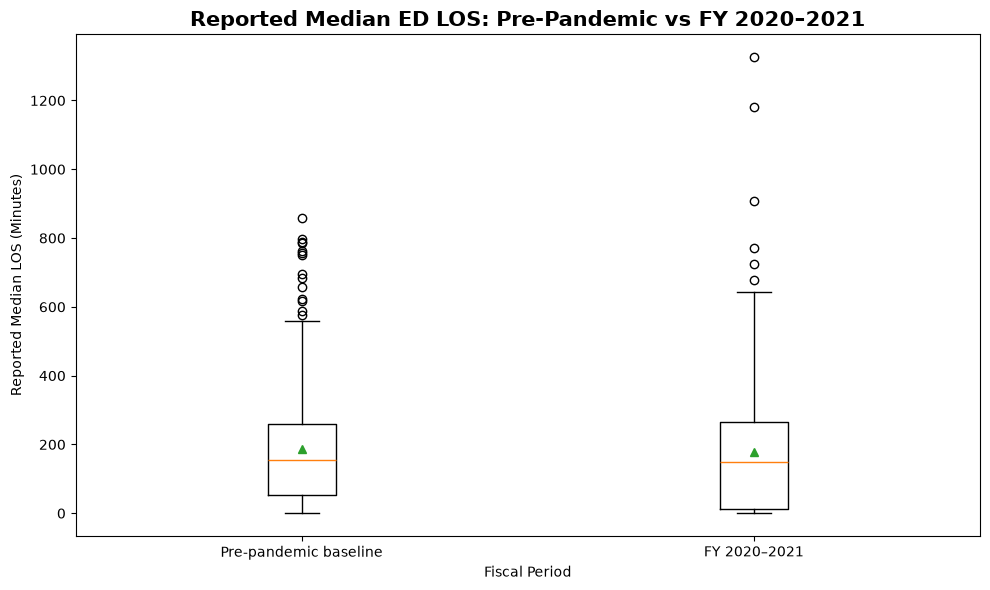

In [17]:
# ============================================================
# VISUALIZATION 1 — MAIN H2 DISTRIBUTION BOXPLOT
# ============================================================

box_data = [
    h2_matched["pre_pandemic_median_los"].to_numpy(),
    h2_matched["pandemic_median_los"].to_numpy()
]

period_labels = [
    "Pre-pandemic baseline",
    "FY 2020–2021"
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    box_data,
    tick_labels=period_labels,
    showmeans=True
)

plt.title(
    "Reported Median ED LOS: Pre-Pandemic vs FY 2020–2021",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Fiscal Period"
)

plt.ylabel(
    "Reported Median LOS (Minutes)"
)

plt.tight_layout()
plt.show()

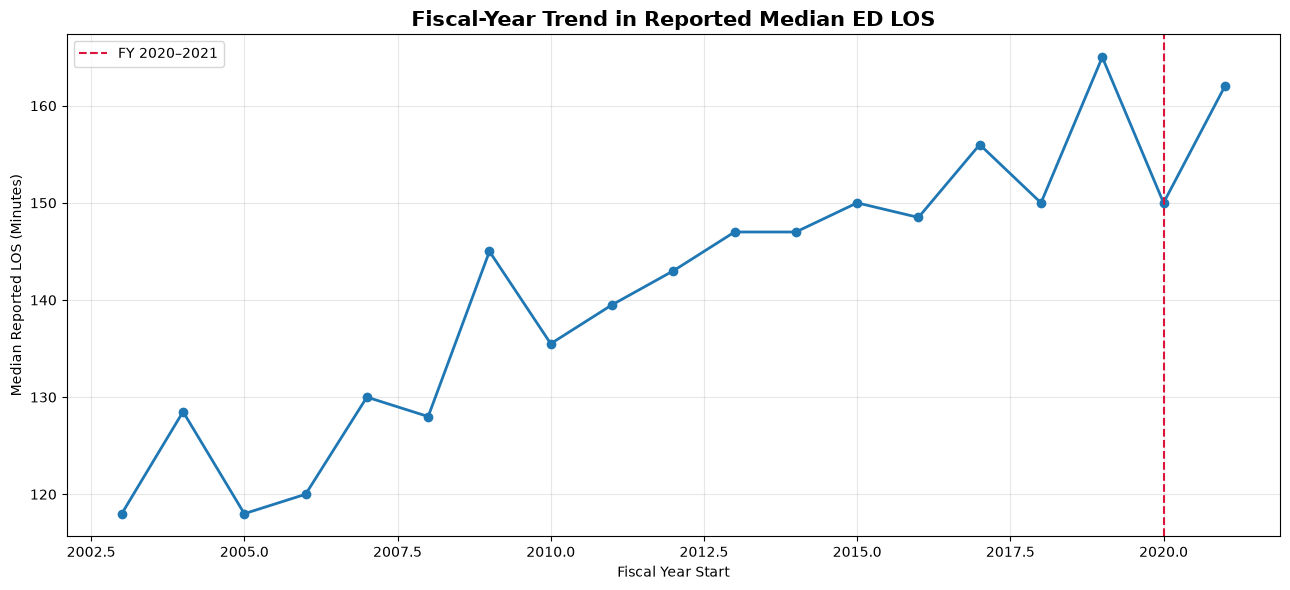

In [18]:
# ============================================================
# VISUALIZATION 2 — FISCAL-YEAR TREND IN REPORTED MEDIAN ED LOS
# ============================================================
# Contextual descriptive visualization across all fiscal years.

year_los = (
    ed_df
    .groupby("fiscal_year_start", observed=True)[
        "median_los_minutes"
    ]
    .median()
    .reset_index(name="median_reported_los")
    .sort_values("fiscal_year_start")
)

plt.figure(figsize=(13, 6))

plt.plot(
    year_los["fiscal_year_start"],
    year_los["median_reported_los"],
    marker="o",
    linewidth=2,
    color="#1f77b4"
)

plt.axvline(
    PANDEMIC_YEAR,
    linestyle="--",
    linewidth=1.5,
    color="crimson",
    label="FY 2020–2021"
)

plt.title(
    "Fiscal-Year Trend in Reported Median ED LOS",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Fiscal Year Start"
)

plt.ylabel(
    "Median Reported LOS (Minutes)"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

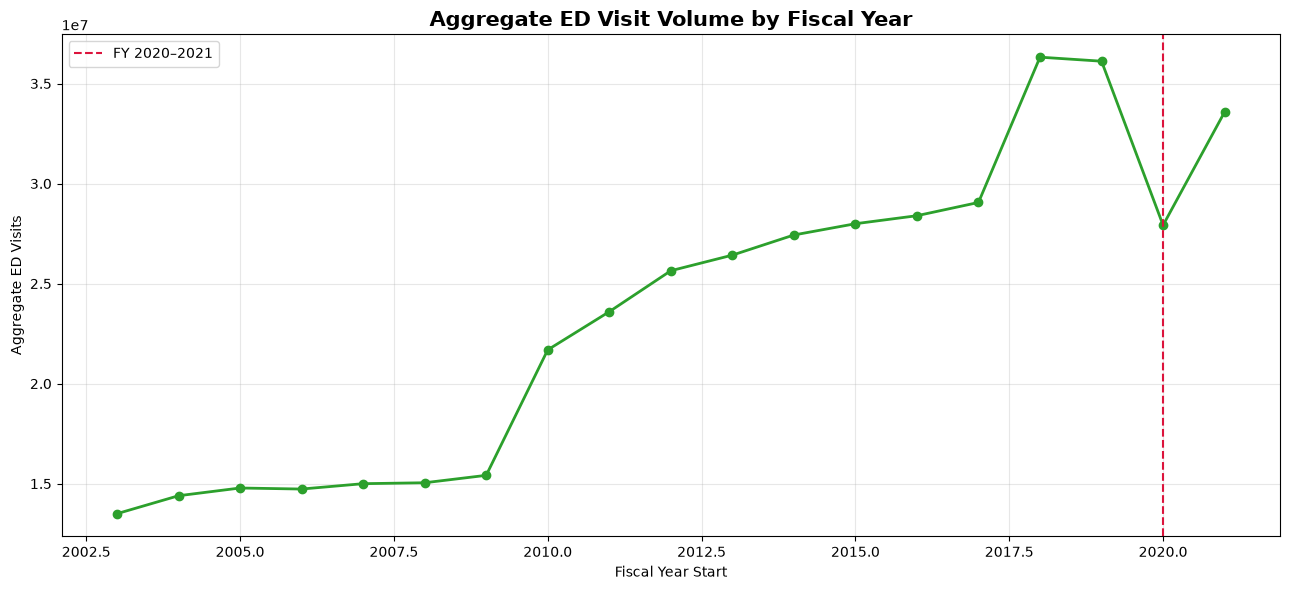

In [19]:
# ============================================================
# VISUALIZATION 3 — AGGREGATE ED VISIT VOLUME CONTEXT
# ============================================================
# Descriptive only: aggregate reported ED visit volume by fiscal year.

year_visits = (
    ed_df
    .groupby("fiscal_year_start", observed=True)[
        "ed_visits"
    ]
    .sum()
    .reset_index(name="total_ed_visits")
    .sort_values("fiscal_year_start")
)

plt.figure(figsize=(13, 6))

plt.plot(
    year_visits["fiscal_year_start"],
    year_visits["total_ed_visits"],
    marker="o",
    linewidth=2,
    color="#2ca02c"
)

plt.axvline(
    PANDEMIC_YEAR,
    linestyle="--",
    linewidth=1.5,
    color="crimson",
    label="FY 2020–2021"
)

plt.title(
    "Aggregate ED Visit Volume by Fiscal Year",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Fiscal Year Start"
)

plt.ylabel(
    "Aggregate ED Visits"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

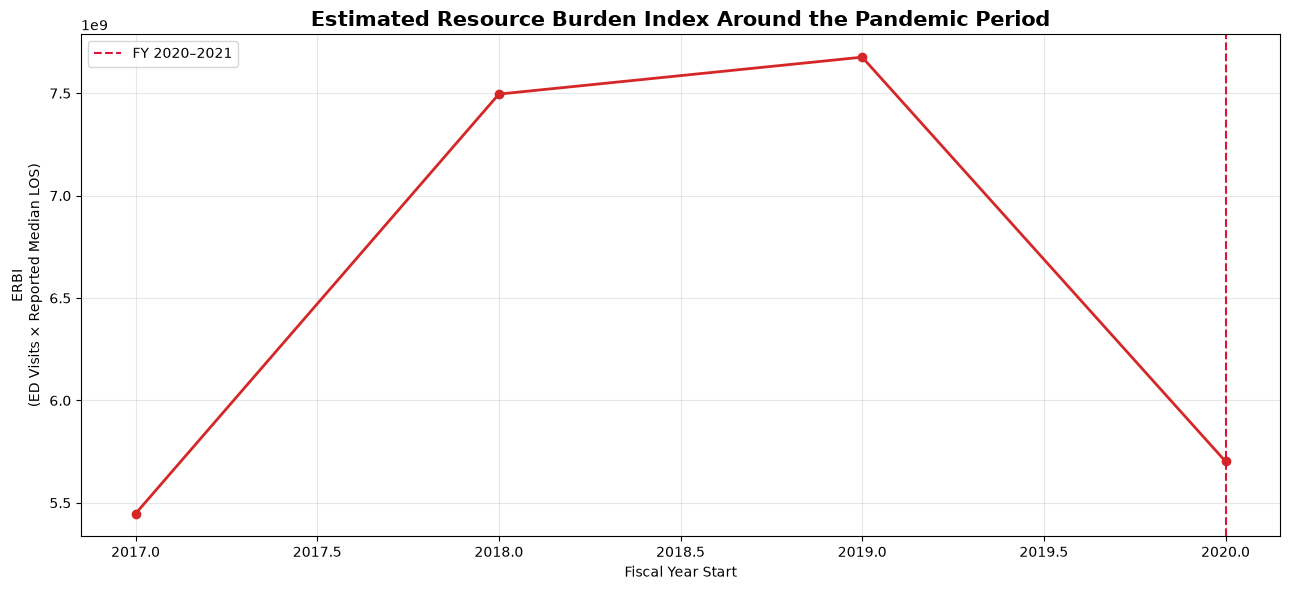

In [20]:
# ============================================================
# VISUALIZATION 4 — ESTIMATED RESOURCE BURDEN INDEX (ERBI)
# ============================================================
# NOTE: ERBI is a resource-burden proxy (ED Visits × Reported Median LOS).
# It is NOT actual total ED minutes or patient-level utilization time.

ed_df["ERBI"] = (
    ed_df["ed_visits"]
    * ed_df["median_los_minutes"]
)

erbi_period = (
    ed_df[
        ed_df["fiscal_year_start"].isin(
            PRE_PANDEMIC_YEARS + [PANDEMIC_YEAR]
        )
    ]
    .groupby("fiscal_year_start", observed=True)["ERBI"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(13, 6))

plt.plot(
    erbi_period["fiscal_year_start"],
    erbi_period["ERBI"],
    marker="o",
    linewidth=2,
    color="#d62728"
)

plt.axvline(
    PANDEMIC_YEAR,
    linestyle="--",
    linewidth=1.5,
    color="crimson",
    label="FY 2020–2021"
)

plt.title(
    "Estimated Resource Burden Index Around the Pandemic Period",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Fiscal Year Start"
)

plt.ylabel(
    "ERBI\n(ED Visits × Reported Median LOS)"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# FINAL H2 RESULTS TABLE
# ============================================================

h2_results = pd.DataFrame({
    "Hypothesis": [
        "H2"
    ],
    "Research_Question": [
        "Did reported median ED LOS differ during FY 2020–2021 compared with the matched pre-pandemic fiscal-year baseline?"
    ],
    "Primary_Test": [
        "Wilcoxon signed-rank test"
    ],
    "Matched_Records": [
        len(h2_matched)
    ],
    "Wilcoxon_Statistic": [
        wilcoxon_statistic
    ],
    "P_Value": [
        p_value
    ],
    "Alpha": [
        ALPHA
    ],
    "Matched_Rank_Biserial": [
        matched_rank_biserial
    ],
    "Median_Difference_Minutes": [
        median_difference
    ],
    "Decision": [
        decision
    ]
})

print("=" * 90)
print("H2 — FINAL HYPOTHESIS TEST RESULTS TABLE")
print("=" * 90)
display(h2_results.round(6))

H2 — FINAL HYPOTHESIS TEST RESULTS TABLE


,Hypothesis,Research_Question,Primary_Test,Matched_Records,Wilcoxon_Statistic,P_Value,Alpha,Matched_Rank_Biserial,Median_Difference_Minutes,Decision
0,H2,Did reported median ED LOS differ during FY 20...,Wilcoxon signed-rank test,384,"14,764.0000",0.0004,0.0500,-0.2440,0.0000,Reject H₀


In [22]:
# ============================================================
# FINAL H2 HUMAN-READABLE RESULT
# ============================================================

print("=" * 90)
print("H2 — FINAL HYPOTHESIS TEST RESULT")
print("=" * 90)

print("\nResearch Question:")
print(
    "Did reported median ED LOS differ during "
    "FY 2020–2021 compared with the matched "
    "pre-pandemic fiscal-year baseline?"
)

print("\nPrimary test:")
print(
    "Wilcoxon signed-rank test on matched "
    "aggregate category observations."
)

print(f"\nWilcoxon statistic (W)          = {wilcoxon_statistic:.4f}")
print(f"p-value                         = {p_value:.10g}")
print(f"Matched rank-biserial (r_rb)    = {matched_rank_biserial:.4f}")
print(f"Median paired difference        = {median_difference:.2f} minutes")
print(f"Mean paired difference          = {mean_difference:.2f} minutes")

print(f"\nDecision: {decision}")
print(f"\nConclusion:\n{conclusion}")

print("\nMethodological limitation:")
print(
    "The analysis uses pre-aggregated ED data. "
    "The matched observations represent combinations "
    "of CTAS level, visit disposition, main problem, "
    "and admission status rather than individual patients. "
    "Therefore, the results describe aggregate-level "
    "differences and should not be interpreted as "
    "individual-patient effects or causal effects of the pandemic."
)

H2 — FINAL HYPOTHESIS TEST RESULT

Research Question:
Did reported median ED LOS differ during FY 2020–2021 compared with the matched pre-pandemic fiscal-year baseline?

Primary test:
Wilcoxon signed-rank test on matched aggregate category observations.

Wilcoxon statistic (W)          = 14764.0000
p-value                         = 0.0004008181377
Matched rank-biserial (r_rb)    = -0.2440
Median paired difference        = 0.00 minutes
Mean paired difference          = -6.86 minutes

Decision: Reject H₀

Conclusion:
There is statistically significant evidence that reported median ED LOS differed between FY 2020–2021 and the matched pre-pandemic baseline.

Methodological limitation:
The analysis uses pre-aggregated ED data. The matched observations represent combinations of CTAS level, visit disposition, main problem, and admission status rather than individual patients. Therefore, the results describe aggregate-level differences and should not be interpreted as individual-patient effect

In [23]:
# ============================================================
# CAPSTONE-READY INTERPRETATION
# ============================================================

print("=" * 90)
print("CAPSTONE INTERPRETATION")
print("=" * 90)

if p_value < ALPHA:
    interpretation_text = (
        f"A Wilcoxon signed-rank test was conducted to determine whether reported median "
        f"emergency-department length of stay differed between FY 2020–2021 and a matched "
        f"pre-pandemic baseline constructed from FY 2017–2018 through FY 2019–2020. The analysis "
        f"compared the same aggregate combinations of triage level, visit disposition, main "
        f"presenting problem, and admission status across the two periods. The test indicated "
        f"a statistically significant difference in reported median ED LOS, W = {wilcoxon_statistic:.2f}, "
        f"p = {p_value:.4g} (p < .001), with a matched rank-biserial correlation of "
        f"{matched_rank_biserial:.4f}. The median paired difference was {median_difference:.2f} minutes "
        f"(mean difference = {mean_difference:.2f} minutes). Therefore, the null hypothesis was rejected. "
        f"Because the underlying NACRS data are pre-aggregated, the finding represents an "
        f"aggregate-level temporal association and should not be interpreted as an individual-patient "
        f"effect or as evidence that the pandemic caused changes in ED LOS."
    )
else:
    interpretation_text = (
        f"A Wilcoxon signed-rank test was conducted to determine whether reported median "
        f"emergency-department length of stay differed between FY 2020–2021 and a matched "
        f"pre-pandemic baseline constructed from FY 2017–2018 through FY 2019–2020. The analysis "
        f"indicated no statistically significant difference in reported median ED LOS, "
        f"W = {wilcoxon_statistic:.2f}, p = {p_value:.4f}. The null hypothesis was not rejected "
        f"because the p-value exceeded α = .05."
    )

print(f"\n{interpretation_text}")

CAPSTONE INTERPRETATION

A Wilcoxon signed-rank test was conducted to determine whether reported median emergency-department length of stay differed between FY 2020–2021 and a matched pre-pandemic baseline constructed from FY 2017–2018 through FY 2019–2020. The analysis compared the same aggregate combinations of triage level, visit disposition, main presenting problem, and admission status across the two periods. The test indicated a statistically significant difference in reported median ED LOS, W = 14764.00, p = 0.0004008 (p < .001), with a matched rank-biserial correlation of -0.2440. The median paired difference was 0.00 minutes (mean difference = -6.86 minutes). Therefore, the null hypothesis was rejected. Because the underlying NACRS data are pre-aggregated, the finding represents an aggregate-level temporal association and should not be interpreted as an individual-patient effect or as evidence that the pandemic caused changes in ED LOS.


In [24]:
# ============================================================
# AGGREGATE STRUCTURE VALIDATION SUMMARY
# ============================================================

print("=" * 80)
print("AGGREGATE STRUCTURE VALIDATION SUMMARY")
print("=" * 80)

print(f"Pre-pandemic fiscal years         : {PRE_PANDEMIC_YEARS}")
print(f"Pandemic fiscal year              : {PANDEMIC_YEAR} (FY {PANDEMIC_YEAR}-{PANDEMIC_YEAR+1})")
print(f"Matching stratification dimensions: {H2_MATCH_COLUMNS}")
print(f"Matched aggregate strata          : {len(h2_matched):,}")
print(f"Duplicate matched strata          : {h2_matched.duplicated(subset=H2_MATCH_COLUMNS).sum()}")
print(f"Wilcoxon test statistic (W)       : {wilcoxon_statistic:.4f}")
print(f"p-value                           : {p_value:.10g}")
print(f"Matched rank-biserial correlation : {matched_rank_biserial:.6f}")
print(f"Median paired difference          : {median_difference:.2f} min")
print(f"Mean paired difference            : {mean_difference:.2f} min")
print(f"Inferential decision              : {decision}")

AGGREGATE STRUCTURE VALIDATION SUMMARY
Pre-pandemic fiscal years         : [2017, 2018, 2019]
Pandemic fiscal year              : 2020 (FY 2020-2021)
Matching stratification dimensions: ['triage_level', 'visit_disposition', 'main_problem', 'admission_status']
Matched aggregate strata          : 384
Duplicate matched strata          : 0
Wilcoxon test statistic (W)       : 14764.0000
p-value                           : 0.0004008181377
Matched rank-biserial correlation : -0.244035
Median paired difference          : 0.00 min
Mean paired difference            : -6.86 min
Inferential decision              : Reject H₀


In [25]:
# ============================================================
# VARIABLE SAFETY CHECK
# ============================================================

required_h2_variables = [
    "wilcoxon_statistic",
    "p_value",
    "ALPHA",
    "matched_rank_biserial",
    "median_difference",
    "decision",
    "conclusion",
    "h2_matched",
    "h2_results",
    "pre_baseline",
    "pre_df",
    "pandemic_df"
]

missing_variables = [
    variable
    for variable in required_h2_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "The following H2 variables are missing: "
        + ", ".join(missing_variables)
    )

print("=" * 80)
print("ALL REQUIRED H2 VARIABLES ARE DEFINED")
print("=" * 80)

for variable in required_h2_variables:
    print(f"  ✓ {variable}")

ALL REQUIRED H2 VARIABLES ARE DEFINED
  ✓ wilcoxon_statistic
  ✓ p_value
  ✓ ALPHA
  ✓ matched_rank_biserial
  ✓ median_difference
  ✓ decision
  ✓ conclusion
  ✓ h2_matched
  ✓ h2_results
  ✓ pre_baseline
  ✓ pre_df
  ✓ pandemic_df


In [26]:
# ============================================================
# SAVE H2 RESULTS TO CSV
# ============================================================

OUTPUT_DIR = Path(
    r"C:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-"
    r"\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-"
    r"\backend\hypothesis testing"
)

results_path = OUTPUT_DIR / "H2_results.csv"
h2_results.to_csv(
    results_path,
    index=False
)
print(f"H2 results saved to:\n{results_path}")

matched_pairs_path = OUTPUT_DIR / "H2_matched_pairs.csv"
h2_matched.to_csv(
    matched_pairs_path,
    index=False
)
print(f"H2 matched pairs saved to:\n{matched_pairs_path}")

print("\nH2 notebook complete.")

H2 results saved to:
C:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\backend\hypothesis testing\H2_results.csv
H2 matched pairs saved to:
C:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\backend\hypothesis testing\H2_matched_pairs.csv

H2 notebook complete.


In [27]:
# End of H2 notebook.
# All cells above implement the matched pre-pandemic baseline + Wilcoxon
# signed-rank test + matched rank-biserial effect size methodology for H2.